In [2]:
%cd ..
# from experiment_control.srs_microscope.srs_microscope import *
from experiment_control.srs_microscope.plot_srs import *
# %matplotlib widget

c:\Users\Goldfish\Documents\Github\experiment_control


# Plot Galvo scan

In [37]:
d_spot = 0.9*u.um
N = 150
Vscan, Lscan = get_Nyquist_vals(N=N, d_spot=d_spot)
print(np.max(ds0['x']) - np.min(ds0['x']))
print((np.max(ds0['x']) - np.min(ds0['x']))/N)
print(np.max(ds0['t']))


scan volt: 0.3872813366541991 volt
scan length: 67.5 micrometer
75.0 micrometer
0.5 micrometer
11.25 second


loading file: GalvoScan_diamond_OEland1074.4-73mW_100uV300us_N150V_6tlia_dspot1um_2025-11-02-20-44-00.h5
importing Dev1...
importing Vsrs_g...
importing Vx...
importing Vy...
importing laser_spot_img...
importing t...
importing wf_img...
importing x...
importing x_img...
importing y...
importing y_img...
importing attr Vx0...
volt
importing attr Vx0_units...
importing attr Vy0...
volt
importing attr Vy0_units...
importing attr dx_dVx...
micrometer / volt
importing attr dx_dVx_units...
importing attr dx_dpix...
micrometer
importing attr dx_dpix_units...
importing attr dy_dVy...
micrometer / volt
importing attr dy_dVy_units...


c:\Users\Goldfish\miniforge3\envs\tidy3d\Lib\site-packages\matplotlib\cbook.py:684: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  x = np.array(x, subok=True, copy=copy)


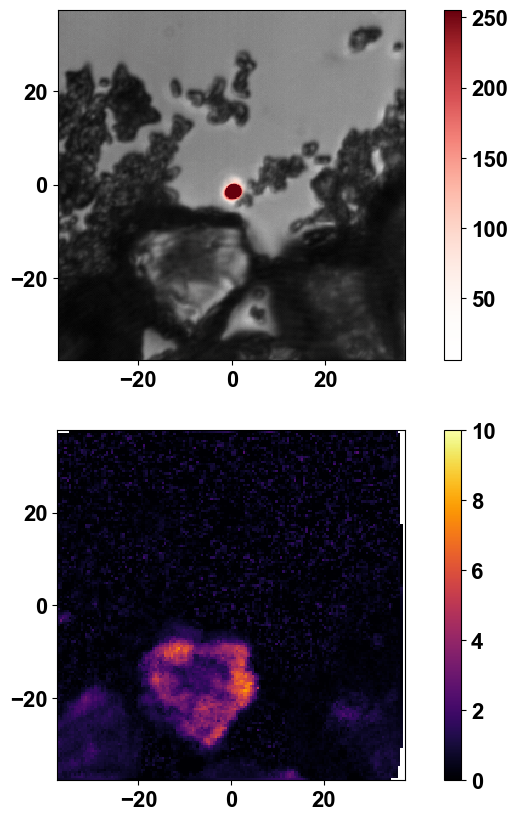

In [2]:
fname = "GalvoScan_diamond_OEland1074.4-73mW_100uV300us_N150V_6tlia_dspot1um_2025-11-02-20-44-00.h5"
dir_name =  "Sample_GSdev1b_Nikon20x_delayvolt16_2025-11-02-18-06-04"

fpath=os.path.join(data_dir, dir_name)
ds0=load_data_from_file(fpath, fname)

%matplotlib inline
fig = plot_scan_data(ds0, wf_cmap=cm.gray, laser_cmap=cm.Reds, srs_cmap=cm.inferno, vmin=0, vmax=10)

# Plot Single Point spectrum

In [16]:
def plot_daq_sweepSpectra(ds0, savefig=False, fname=None, fpath=None, figsize=(5,6), wavvolt_HVCALIB=wavvolt_HVCALIB, verbose=True, fig=None, ax=None):
    #First point in sweep already removed in unwrap_sweep()
    HVA_Vset = ds0["HVA_Vset"]
    wavelength_set = ds0["wavelength_set"]
    HV_arr = ds0["HV_arr"]
    raman_shift = ds0["raman_shift"] #sorted in order of increasing voltage

    rs_sort = np.sort(raman_shift) #sorted by ascending wavelength (ascending raman_shift for tuning Stokes wavelength)

    offset = 0*u.V
    Vsrs_arr = (ds0["Vsrs_arr"] / 10 + offset).to(u.V).m * ds0["sens_lia"].to(u.V)

    Vsrs_interp_arr = calibrate_sweepSpectra(wavelength_set, Vsrs_arr, HV_arr, HVA_Vset, wavvolt_HVCALIB=wavvolt_HVCALIB)
    VCSEL_wavmon_arr = ds0["VCSEL_wavmon_arr"]

    Vsrs_av = np.mean(Vsrs_interp_arr, axis=0)
    uncal_Vsrs_av = np.mean(Vsrs_arr, axis=0)
    
    mind = np.nanargmax(Vsrs_av)
    mind_uncal = np.nanargmax(uncal_Vsrs_av)
    
    print("Calib Peak at {:2.3f}".format(rs_sort[mind]))
    print(f"Uncal Peak at {raman_shift[mind_uncal] :2.3f}")

    if ax is None:
        if verbose:
            fig, ax = plt.subplots(3, 1, figsize=figsize, tight_layout=True)
        else:
            fig, ax = plt.subplots(1, 1, figsize=figsize, tight_layout=True)
    
    if verbose:
        for spec in range(Vsrs_arr.shape[0]):
            ax[0].plot(raman_shift, Vsrs_arr[spec].to(u.uV))
            ax[1].plot(rs_sort, Vsrs_interp_arr[spec].to(u.uV))
        
        ax[2].plot(rs_sort, Vsrs_av.to(u.uV))
        ax[2].plot(rs_sort[mind].m, Vsrs_av[mind].to(u.uV).m, 'x')
        # ax[2].plot(raman_shift, np.mean(Vsrs_arr, axis=0).to(u.uV), 'k')
        ax[0].set_ylabel("Voltage $(\mu V)$")
        ax[0].set_xlim((np.min(raman_shift.m), np.max(raman_shift.m)))
        ax[1].set_ylabel("Voltage $(\mu V)$")
        ax[1].set_xlim((np.min(raman_shift.m), np.max(raman_shift.m)))
        ax[2].set_xlabel("Raman Shift (1/cm)")
        ax[2].set_ylabel("Voltage $(\mu V)$")
        ax[2].set_xlim((np.min(raman_shift.m), np.max(raman_shift.m)))
    else:
        ax.plot(rs_sort, Vsrs_av.to(u.uV))
        ax.set_xlabel("Raman Shift (1/cm)")
        ax.set_ylabel("Voltage $(\mu V)$")
        ax.set_xlim((np.min(raman_shift.m), np.max(raman_shift.m)))
    
    if savefig:
        fname=os.path.normpath(os.path.join(fpath,fname))
        plt.savefig(fname, dpi=None, facecolor=None, edgecolor=None,
            orientation='portrait', transparent=True, bbox_inches=None, pad_inches=0.5)
    return fig, ax

<>:39: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:44: SyntaxWarning: invalid escape sequence '\m'
<>:49: SyntaxWarning: invalid escape sequence '\m'
<>:39: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:44: SyntaxWarning: invalid escape sequence '\m'
<>:49: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Goldfish\AppData\Local\Temp\ipykernel_30516\2257695934.py:39: SyntaxWarning: invalid escape sequence '\m'
  ax[0].set_ylabel("Voltage $(\mu V)$")
C:\Users\Goldfish\AppData\Local\Temp\ipykernel_30516\2257695934.py:41: SyntaxWarning: invalid escape sequence '\m'
  ax[1].set_ylabel("Voltage $(\mu V)$")
C:\Users\Goldfish\AppData\Local\Temp\ipykernel_30516\2257695934.py:44: SyntaxWarning: invalid escape sequence '\m'
  ax[2].set_ylabel("Voltage $(\mu V)$")
C:\Users\Goldfish\AppData\Local\Temp\ipykernel_30516\2257695934.py:49: SyntaxWarning: invalid escape sequence '\m'
  ax.set_yla

loading file: Spectra_diamondCarotenoid_FFP-I_60dB_0.5nmStep_100us300uV_2025-11-02-19-02-39.h5
importing Dev2...
importing HVA_Vraw...
importing HVA_Vset...
importing HV_arr...
importing VCSEL_wavmon_arr...
importing VCSEL_wavmon_raw...
importing VOA_Vset...
importing Vsrs_Vraw...
importing Vsrs_arr...
importing raman_shift...
importing t...
importing wavelength_set...
importing attr num_sweep...
importing attr pump_wav...
nanometer
importing attr pump_wav_units...
importing attr sens_lia...
millivolt
importing attr sens_lia_units...
importing attr t_lia...
millisecond
importing attr t_lia_units...
importing attr wav_start...
nanometer
importing attr wav_start_units...
importing attr wav_stop...
nanometer
importing attr wav_stop_units...
importing attr Δwav...
nanometer
importing attr Δwav_units...
Calib Peak at 1339.372 / centimeter
Uncal Peak at 1339.372 / centimeter


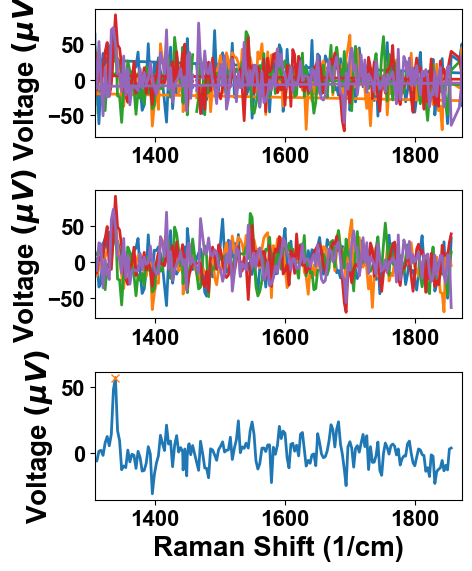

In [24]:
%matplotlib inline
fpath = os.path.join(data_dir,"Sample_GSdev1b_Nikon20x_delayvolt16_2025-11-02-18-06-04")
fname = "Spectra_diamondCarotenoid_FFP-I_60dB_0.5nmStep_100us300uV_2025-11-02-19-02-39.h5"
ds0 = load_data_from_file(fpath, fname)

# wavvolt_test = os.path.join(calib_dir, "wavvolt_dev1b_15C_CW976_boa_0.00mW_2025-10-11_FIXED2.mat") #For wavelength set

savepath = None
fname = None
fig = plot_daq_sweepSpectra(ds0, wavvolt_HVCALIB=wavvolt_HVCALIB)
plt.show()
# fig = plot_daq_sweepSpectra(ds0, savefig=False, fname=None, fpath=None, wavvolt_HVCALIB=wavvolt_file)


loading file: Spectra_Carotenoid_FFP-I_60dB_0.5nmStep_300us300uV_2025-11-02-19-03-48.h5
importing Dev2...
importing HVA_Vraw...
importing HVA_Vset...
importing HV_arr...
importing VCSEL_wavmon_arr...
importing VCSEL_wavmon_raw...
importing VOA_Vset...
importing Vsrs_Vraw...
importing Vsrs_arr...
importing raman_shift...
importing t...
importing wavelength_set...
importing attr num_sweep...
importing attr pump_wav...
nanometer
importing attr pump_wav_units...
importing attr sens_lia...
millivolt
importing attr sens_lia_units...
importing attr t_lia...
millisecond
importing attr t_lia_units...
importing attr wav_start...
nanometer
importing attr wav_start_units...
importing attr wav_stop...
nanometer
importing attr wav_stop_units...
importing attr Δwav...
nanometer
importing attr Δwav_units...
loading file: Spectra_Bcarotene_FFP_GS_step0.1nm_300us300uV_5tlia_60dB_10reps_2_2025-11-07-17-13-17.h5
importing Dev2...
importing HVA_Vraw...
importing HVA_Vset...
importing HV_arr...
importing VC

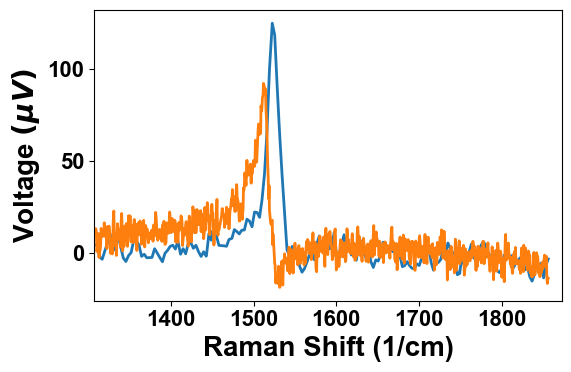

In [25]:
fpath = os.path.join(data_dir,"Sample_GSdev1b_Nikon20x_delayvolt16_2025-11-02-18-06-04")
fname = "Spectra_Carotenoid_FFP-I_60dB_0.5nmStep_300us300uV_2025-11-02-19-03-48.h5"
ds0 = load_data_from_file(fpath, fname)

fname1 = "Spectra_Bcarotene_FFP_GS_step0.1nm_300us300uV_5tlia_60dB_10reps_2_2025-11-07-17-13-17.h5"
ds1 = load_data_from_file(fpath, fname1)

# fname2 = "Spectra_Bcarotene_FFP_GS_step0.1nm_100us300uV_5tlia_60dB_10reps_2025-11-07-17-16-49.h5"
# ds2 = load_data_from_file(fpath, fname2)


fig, ax = plot_daq_sweepSpectra(ds0, wavvolt_HVCALIB=wavvolt_HVCALIB, verbose=False, figsize=(6,4))
fig, ax = plot_daq_sweepSpectra(ds1, wavvolt_HVCALIB=wavvolt_HVCALIB, verbose=False, figsize=(6,4), fig=fig, ax=ax)
# fig, ax = plot_daq_sweepSpectra(ds2, wavvolt_HVCALIB=wavvolt_HVCALIB, verbose=False, figsize=(6,4), fig=fig, ax=ax)
plt.show()

# Plot Raw Hyperspectral Image

In [15]:
d_spot = 1.8*u.um
N = 150
Vscan, Lscan = get_Nyquist_vals(N=N, d_spot=d_spot, scale=2.3)
print(np.max(ds['x']) - np.min(ds['x']))
print((np.max(ds['x']) - np.min(ds['x']))/N)
# print(np.max(ds0['t']))

scan volt: 0.6735327593986071 volt
scan length: 117.3913043478261 micrometer
step size: 0.782608695652174 micrometer
117.3913043478261 micrometer
0.782608695652174 micrometer


loading file: HyperspecImg_Nikon20x_N150_CaroteneDiamond_1nm_300us1mV_72min_5tlia_12dbdec_scale2.3dspot1.8um_spot2_2025-11-08-22-16-00.h5
importing Dev1...
importing Dev2...
importing HV_g...
importing HV_pix...
importing VCSEL_wavmon_g...
importing VCSEL_wavmon_pix...
importing Vsrs_g...
importing Vsrs_pix...
importing Vx...
importing Vy...
importing laser_spot_img...
importing raman_shift...
importing t...
importing t_scan...
importing t_sweep...
importing wavelength_set...
importing wavset_sort...
importing wf_img...
importing x...
importing x_img...
importing y...
importing y_img...
importing attr Vx0...
volt
importing attr Vx0_units...
importing attr Vy0...
volt
importing attr Vy0_units...
importing attr dx_dVx...
micrometer / volt
importing attr dx_dVx_units...
importing attr dx_dpix...
micrometer
importing attr dx_dpix_units...
importing attr dy_dVy...
micrometer / volt
importing attr dy_dVy_units...
importing attr num_sweep...
importing attr pump_wav...
nanometer
importing attr

c:\Users\Goldfish\miniforge3\envs\tidy3d\Lib\site-packages\matplotlib\cbook.py:684: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  x = np.array(x, subok=True, copy=copy)


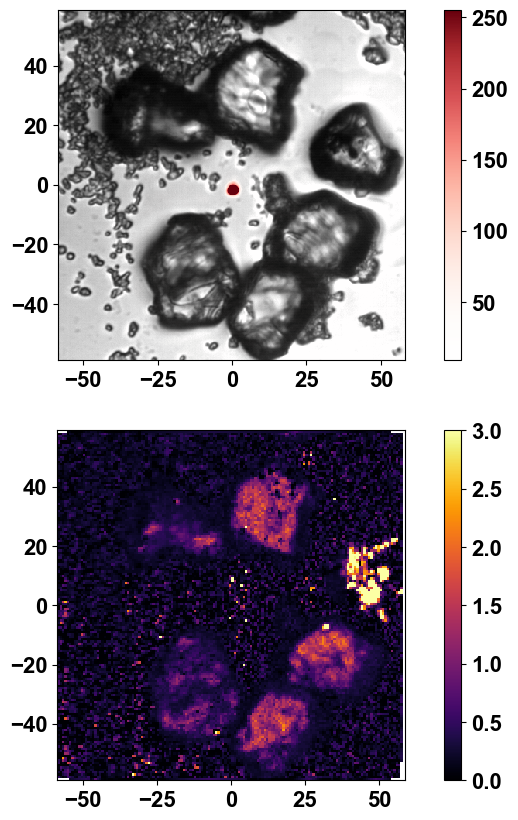

In [53]:
fpath = os.path.join(data_dir, "Sample_GSdev1b_hyperspectral_image_2025-11-02-19-20-23")
fname = "HyperspecImg_Nikon20x_N150_CaroteneDiamond_1nm_300us1mV_72min_5tlia_12dbdec_scale2.3dspot1.8um_spot2_2025-11-08-22-16-00"
 
ds = load_data_from_file(fpath, fname + ".h5")
Vsrs_hs = xr.open_dataarray(os.path.join(fpath, fname + ".nc"))
%matplotlib inline

wavnum = 1341/ u.cm
fig = plot_hyperspectral_scan(ds, Vsrs_hs, wavnum, wf_cmap=cm.gray, laser_cmap=cm.Reds, srs_cmap=cm.inferno, vmin=0, vmax=3, wf_offsets=None, plot_wf=True)
plt.show()

Peak at 1341.572465704693 1/cm
Peak at 1341.1052473654543 1/cm
Peak at 1341.1052473654543 1/cm


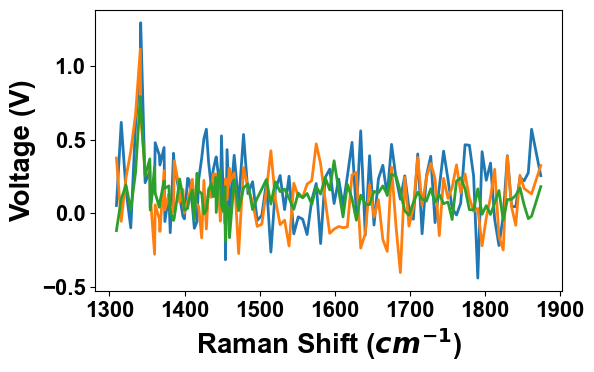

In [55]:
def plot_pixel_spec(Vsrs_hs, x, y, ax=None, fig=None):
    """
    Plot the spectra at the specified x,y cooridnate
    """
    spec = Vsrs_hs.sel(x=x, y=-y, method="nearest")
    pk_shift = spec.idxmax(dim="raman_shift")
    print(f"Peak at {pk_shift.values} 1/cm")

    if ax is None:
        fig, ax = plt.subplots(1,1, figsize=(6,4), tight_layout=True)
    ax.plot(Vsrs_hs["raman_shift"], spec)
    ax.set_xlabel("Raman Shift ($cm^{-1}$)")
    ax.set_ylabel("Voltage (V)")
    return fig, ax


%matplotlib inline
fig, ax = plot_pixel_spec(Vsrs_hs, x=12, y=-40)
fig, ax = plot_pixel_spec(Vsrs_hs, x=12, y=30, ax=ax, fig=fig)
fig, ax = plot_pixel_spec(Vsrs_hs, x=40, y=-10, ax=ax, fig=fig)
# fig, ax = plot_pixel_spec(Vsrs_hs, x=20, y=0)
# fig, ax = plot_pixel_spec(Vsrs_hs, x=-20, y=50, ax=ax, fig=fig)
# fig, ax = plot_pixel_spec(Vsrs_hs, x=-50, y=30, ax=ax, fig=fig)
plt.show()

In [69]:
spec = Vsrs_hs.sel(x=x, y=-y, method="nearest")
# m_ind = spec.idxmax#np.argmax(np.asarray(spec))
# pk_shift = Vsrs#Vsrs_hs["raman_shift"][m_ind]
# pk_shift = spec.max(dim="raman_shift")
# print(pk_shift)
pk_shift = spec.idxmax(dim="raman_shift")
print(pk_shift.values)



1341.1052473654543


In [ ]:
# ds['sens_lia']
d_spot = 1.8*u.um
N = 100
Vscan, Lscan = get_Nyquist_vals(N=N, d_spot=d_spot)
print(np.max(ds['x']) - np.min(ds['x']))
print((np.max(ds['x']) - np.min(ds['x']))/N)


scan volt: 0.5163751155389321 volt
scan length: 90.0 micrometer
step size: 0.9 micrometer
115.19999999999999 micrometer
1.152 micrometer


In [ ]:
# # From process_hyperspectral_scan
# # Fix bug in galvo unwrapping in 1st 3 datasets
# # save reprocessed data in new hdf5 file


# t_scan = ds["t_scan"]
# t_sweep = ds["t_sweep"]
# pad = 5
# offset = 0
# nx = ds['Vsrs_g'].shape[0]
# ny = ds['Vsrs_g'].shape[1]

# # d_spot = 1.8*u.um
# # N = nx
# # Vscan, Lscan = get_Nyquist_vals(N=N, d_spot=d_spot)
# pad_galvo_endpts = 1
# fixed_wav = 1074.4 * u.nm

# ΔVx = 0.516*u.V
# ΔVy = ΔVx

# #Sort wavelength by ascending order and remove repeated values
# # s_ind = np.argsort(wavelength_set)
# # wavset_sort = wavelength_set[s_ind]
# wavset_sort, s_ind = np.unique(ds["wavelength_set"].to(u.nm).m, return_index=True)
# wavset_sort = wavset_sort * u.nm

# Vsrs_raw = ds['Dev2']['ai0']
# HV_raw = Vmon_to_HVA(ds['Dev2']['ai1'])
# VCSEL_wavmon_raw = ds['Dev2']['ai3']

# #Remove padded samples at endpoints of daq2 arrays
# Vsrs_raw = Vsrs_raw[pad:-pad]
# HV_raw = HV_raw[pad:-pad]
# VCSEL_wavmon_raw = VCSEL_wavmon_raw[pad:-pad]

# #Reshape into 2d array with n_pix rows
# num_pix = nx*ny 
# npix = num_pix + 1
# N_wav = Vsrs_raw.shape[0] // npix
# N_unqwav = s_ind.shape[0]

# print(f"npix: {npix}")
# print(f"Vsrs_raw.shape[0]: {Vsrs_raw.shape[0]}")
# print(f"N_wav: {N_wav}")
# print(f"N_unqwav: {N_unqwav}")

# Vsrs_pix = np.reshape(np.array(Vsrs_raw.to(u.V).m), (npix, N_wav))
# HV_pix = np.reshape(np.array(HV_raw.to(u.V).m), (npix, N_wav))
# VCSEL_wavmon_pix = np.reshape(np.array(VCSEL_wavmon_raw.to(u.V).m), (npix, N_wav))

# #Discard 1st pixel sweep (first row) - galvo ai reads garbage here
# #Discard pad_galvo_endpts points from the start of each row - vcsel ai lags ao
# Vsrs_pix = Vsrs_pix[:-1,pad_galvo_endpts:]
# HV_pix = HV_pix[:-1,pad_galvo_endpts:] 
# VCSEL_wavmon_pix = VCSEL_wavmon_pix[:-1,pad_galvo_endpts:]


# # Initialize arrays for pixel x spectra with sorted, unique spectral points
# Vsrs_unqpix = np.zeros((num_pix, N_unqwav))
# HV_unqpix = np.zeros((num_pix, N_unqwav))
# VCSEL_wavmon_unqpix = np.zeros((num_pix, N_unqwav))

# #Odd pixels are backward sweeps - flip (Assumes only 1 num_sweeps per pix is 1)
# for row in range(Vsrs_pix.shape[0]):
#     if row % 2 != 0:
#         Vsrs_pix[row,:] = Vsrs_pix[row,::-1]
#         HV_pix[row,:] = HV_pix[row,::-1]
#         VCSEL_wavmon_pix[row,:] = VCSEL_wavmon_pix[row,::-1]
#     # Sort columns (wavelength sweep) by ascending order and remove repeated values
#     Vsrs_unqpix[row,:] = Vsrs_pix[row, s_ind]
#     HV_unqpix[row,:] = HV_pix[row, s_ind]
#     VCSEL_wavmon_unqpix[row,:] = VCSEL_wavmon_pix[row, s_ind]
    
# #Interpolate each wavelength to measured pixel grid
# Vx_meas = ds['Dev1']['ai2'][1:] #discard 1st ai value (ai lags ao by 1 sample point)
# Vy_meas = ds['Dev1']['ai3'][1:] #discard 1st ai value (ai lags ao by 1 sample point)

# Vx,Vy = scan_vals(nx,ny,ΔVx,ΔVy,Vx0,Vy0)
# Vx_g, Vy_g = np.meshgrid(Vx.m,Vy.m)

# Vsrs_g = np.zeros((nx, ny, N_unqwav))
# HV_g = np.zeros((nx, ny, N_unqwav))
# VCSEL_wavmon_g = np.zeros((nx, ny, N_unqwav))

# for hvind in range(Vsrs_unqpix.shape[1]):
#     Vsrs_g[:,:, hvind] = griddata((Vx_meas.m, Vy_meas.m), Vsrs_unqpix[:, hvind], (Vx_g, Vy_g)) * u.volt
#     #No interpolation necessary for HV, use griddata to reshape array
#     HV_g[:,:, hvind] = unwrap_scan(HV_unqpix[:,hvind], nx, ny) * u.volt
#     VCSEL_wavmon_g[:,:,hvind] = unwrap_scan(VCSEL_wavmon_unqpix[:,hvind], nx, ny) * u.volt
    
# x = ((Vx-Vx0)*dx_dVx).to(u.um)
# y = ((Vy-Vy0)*dy_dVy).to(u.um)

# #Convert wavelength_set to wavenumber
# raman_shift = (1/fixed_wav - 1/wavset_sort).to(1/u.cm)

# #Store hs-image into xarray
# Vsrs_hs = hs_xarray(data=Vsrs_g, x=x, y=y, raman_shift=raman_shift)
#     # HV_hs = hs_xarray(data=HV_g, x=x, y=y, wavelength=wavelength_set, raman_shift=raman_shift)
    
# # Store hs-image data and additional info into proc_data dict
# proc_data = {
#     "Vx"                : Vx,
#     "Vy"                : Vy,
#     "dx_dVx"            : dx_dVx,
#     "dy_dVy"            : dy_dVy,
#     "x"                 : x,
#     "y"                 : y,
#     "Vsrs_pix"          : Vsrs_unqpix,
#     "HV_pix"            : HV_unqpix,
#     "VCSEL_wavmon_pix"  : VCSEL_wavmon_unqpix,
#     "Vsrs_g"            : Vsrs_g,
#     "raman_shift"       : raman_shift,
#     "wavset_sort"       : wavset_sort,
#     "HV_g"              : HV_g,
#     "VCSEL_wavmon_g"    : VCSEL_wavmon_g,
#     "t_scan"            : t_scan,
#     "t_sweep"           : t_sweep
# }



npix: 25601
Vsrs_raw.shape[0]: 3276928
N_wav: 128
N_unqwav: 117


C:\Users\Goldfish\AppData\Local\Temp\ipykernel_11580\2750487880.py:94: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  Vsrs_g[:,:, hvind] = griddata((Vx_meas.m, Vy_meas.m), Vsrs_unqpix[:, hvind], (Vx_g, Vy_g)) * u.volt
C:\Users\Goldfish\AppData\Local\Temp\ipykernel_11580\2750487880.py:96: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  HV_g[:,:, hvind] = unwrap_scan(HV_unqpix[:,hvind], nx, ny) * u.volt
C:\Users\Goldfish\AppData\Local\Temp\ipykernel_11580\2750487880.py:97: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  VCSEL_wavmon_g[:,:,hvind] = unwrap_scan(VCSEL_wavmon_unqpix[:,hvind], nx, ny) * u.volt


SyntaxError: 'return' outside function (2750487880.py, line 129)

C:\Users\Goldfish\AppData\Local\Temp\ipykernel_11580\4125421286.py:4: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  temp[:,:, hvind] = unwrap_scan(Vsrs_unqpix[:,hvind], nx, ny) * u.volt


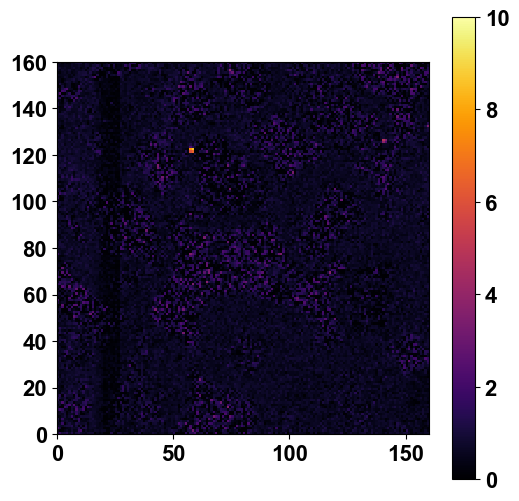

In [16]:
temp = np.zeros((nx, ny, Vsrs_unqpix.shape[1]))
for hvind in range(Vsrs_unqpix.shape[1]):
    #No interpolation necessary for HV, use griddata to reshape array
    temp[:,:, hvind] = unwrap_scan(Vsrs_unqpix[:,hvind], nx, ny) * u.volt
    

fig, ax = plt.subplots(1,1,figsize=(6,6))
p0 = ax.pcolormesh(np.flipud(np.transpose(temp[:,:,10])), cmap=cm.inferno, vmin=0, vmax=10)
cb1 = plt.colorbar(p0, ax=ax)
ax.set_aspect("equal")
plt.show()

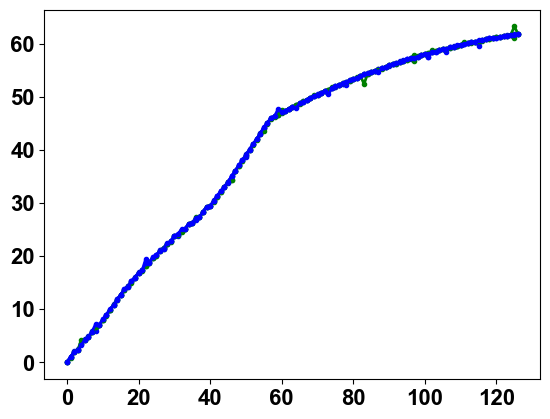

In [ ]:

# plt.figure()
# # for row in range(Vsrs_pix.shape[0]):
# for row in range(30,35):
#     if row %2 == 0:
#         plt.plot(HV_pix[row], '.-', color='b')
#     else:
#         plt.plot(HV_pix[row], '.-', color='g')

# plt.show()

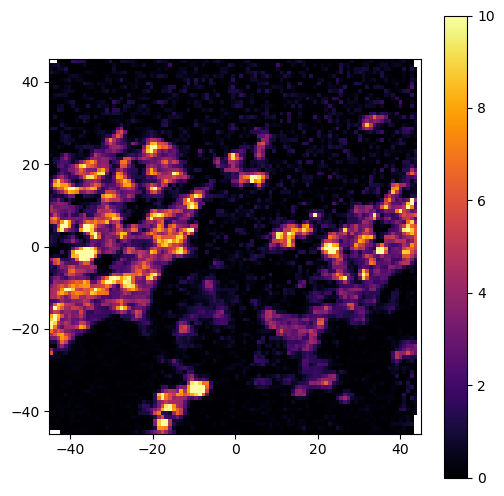

In [ ]:
# print(ds['Vsrs_g'].shape)
# from copy import deepcopy
# %matplotlib inline

# wavnum = 1513/ u.cm

# Vsrs_2d = np.asarray(Vsrs_hs.sel(raman_shift=wavnum, method="nearest")) 

# fig, ax = plt.subplots(1,1,figsize=(6,6))
# p0 = ax.pcolormesh(Vsrs_hs["y"], Vsrs_hs["x"], np.flipud(np.transpose(Vsrs_2d)), cmap=cm.inferno, vmin=0, vmax=10)
# cb1 = plt.colorbar(p0, ax=ax)
# ax.set_aspect("equal")

In [ ]:
# sample_dir = "GSdev1b_hyperspectral_image_2025-11-02-19-20-23"
# resave_fname = "HyperspecImg_Nikon20x_N150_CaroteneDiamond_0.5nm_0.3ms_50min_2025-11-02-19-20-23_FIXGALVO"
# # ds = load_data_from_file(fpath, fname + ".h5")
# # Vsrs_hs = xr.open_dataarray(os.path.join(fpath, fname + ".nc"))
# sample_dir = resolve_sample_dir(sample_dir, data_dir=data_dir)

# fpath = new_path(name=resave_fname,data_dir=sample_dir,ds_type='HyperspecImg',extension='h5',timestamp=True)
# xrpath = new_path(name=resave_fname,data_dir=sample_dir,ds_type='HyperspecImg',extension='nc',timestamp=True)
# print("saving data to: ")
# print(fpath)
# print(xrpath)

# dump_hdf5(
#     {   'wf_img': ds["wf_img"],
#         'laser_spot_img': ds["laser_spot_img"],
#         'dx_dpix': ds["dx_dpix"],
#         'x_img': ds["x_img"],
#         'y_img': ds["y_img"],
#         "dx_dVx" : ds["dx_dVx"],
#         "dy_dVy" : ds["dy_dVy"],
#         "Vx0" : ds["Vx0"],
#         "Vy0" : ds["Vy0"],
#         'num_sweep': ds["num_sweep"],
#         't_lia': ds["t_lia"],
#         'sens_lia': ds["sens_lia"],
#         'wav_start': ds["wav_start"],
#         'wav_stop': ds["wav_stop"],
#         'Δwav': ds["Δwav"],
#         'wavelength_set': ds["wavelength_set"],  # Sorted by increasing voltage (same as HV_set)
#         'pump_wav': ds["pump_wav"]
#     },
#     fpath,
#     open_mode='x',
#     )

# dump_hdf5(proc_data, fpath)
# ds2 = load_hdf5(fpath=fpath)
# Vsrs_hs.to_netcdf(xrpath)


saving data to: 
C:\Users\euyehara\OneDrive\Documents\data\srs_microscope\Sample_GSdev1b_hyperspectral_image_2025-11-02-19-20-23\HyperspecImg_HyperspecImg_Nikon20x_N150_CaroteneDiamond_0.5nm_0.3ms_50min_2025-11-02-19-20-23_FIXGALVO_2025-11-05-18-29-06.h5
C:\Users\euyehara\OneDrive\Documents\data\srs_microscope\Sample_GSdev1b_hyperspectral_image_2025-11-02-19-20-23\HyperspecImg_HyperspecImg_Nikon20x_N150_CaroteneDiamond_0.5nm_0.3ms_50min_2025-11-02-19-20-23_FIXGALVO_2025-11-05-18-29-06.nc
dumping item: wf_img
dumping item: laser_spot_img
dumping item: dx_dpix
non-array, non-list item with units:
micrometer
dumping item: x_img
dumping item: y_img
dumping item: dx_dVx
non-array, non-list item with units:
micrometer / volt
dumping item: dy_dVy
non-array, non-list item with units:
micrometer / volt
dumping item: Vx0
non-array, non-list item with units:
volt
dumping item: Vy0
non-array, non-list item with units:
volt
dumping item: num_sweep
non-array, non-list item without units
dumping item

c:\Users\euyehara\miniconda3\envs\instrumental\Lib\site-packages\matplotlib\cbook.py:733: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  x = np.array(x, subok=True, copy=copy)


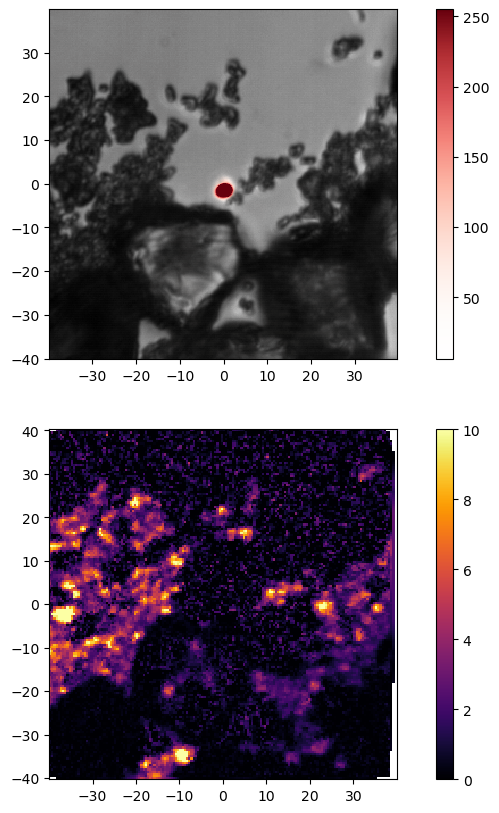

In [734]:
%matplotlib inline
wavnum = 1511/ u.cm
fig = plot_hyperspectral_scan(ds2, Vsrs_hs, wavnum, wf_cmap=cm.gray, laser_cmap=cm.Reds, srs_cmap=cm.inferno, vmin=0, vmax=10, wf_offsets=None, plot_wf=True)

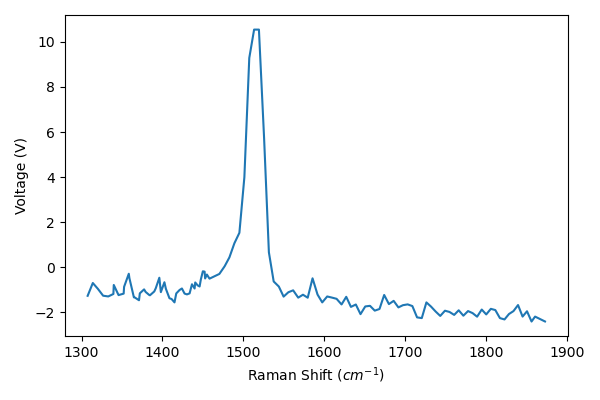

In [662]:
x=-10
y=-33

%matplotlib widget
fig = plot_pixel_spec(Vsrs_hs, x=x, y=y)

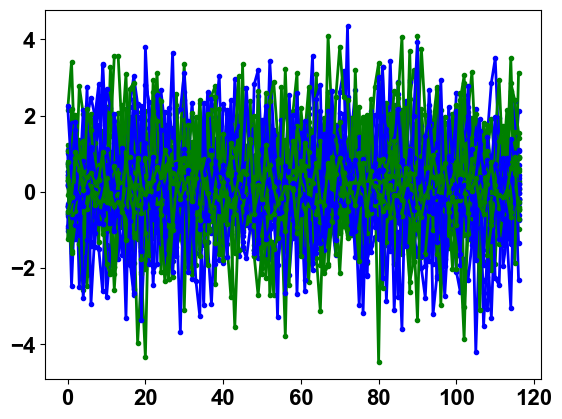

In [87]:
plt.figure()
# for row in range(Vsrs_pix.shape[0]):
for row in range(60,100):
    if row %2 == 0:
        plt.plot(ds["Vsrs_pix"][row], '.-', color='b')
        # plt.plot(Vsrs_unqpix[row], '.-', color='b')
    else:
        plt.plot(ds["Vsrs_pix"][row], '.-', color='g')
        # plt.plot(Vsrs_unqpix[row], '.-', color='g')
plt.show()

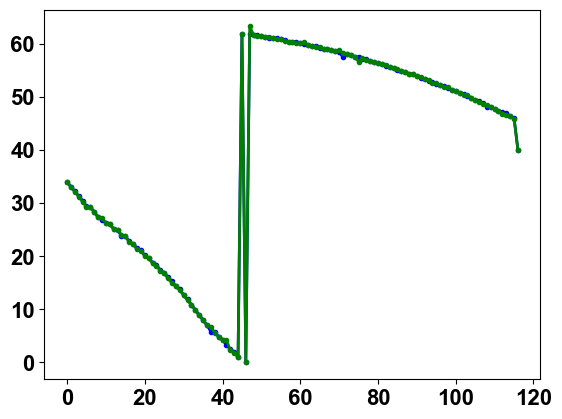

In [57]:

plt.figure()
# for row in range(Vsrs_pix.shape[0]):
for row in range(30,32):
    if row %2 == 0:
        plt.plot(ds["HV_pix"][row], '.-', color='b')
    else:
        plt.plot(ds["HV_pix"][row], '.-', color='g')

plt.show()

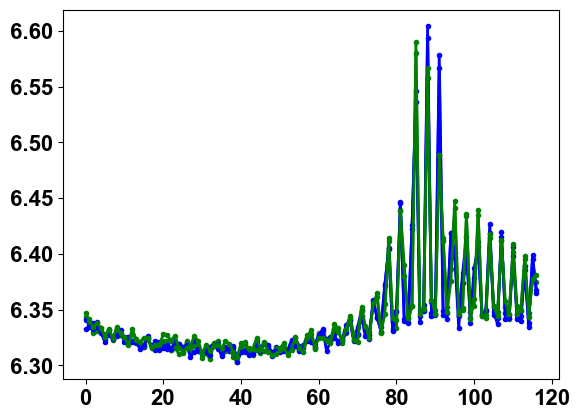

In [56]:
%matplotlib inline
plt.figure()
# for row in range(Vsrs_pix.shape[0]):
for row in range(30,34):
    if row %2 == 0:
        plt.plot(ds["VCSEL_wavmon_pix"][row], '.-', color='b')
    else:
        plt.plot(ds["VCSEL_wavmon_pix"][row], '.-', color='g')
plt.show()

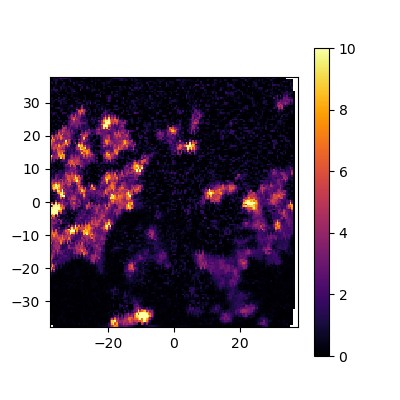

In [307]:
wavnum = 1516/ u.cm
fig = plot_hyperspectral_scan(ds, Vsrs_hs, wavnum, wf_cmap=cm.gray, laser_cmap=cm.Reds, srs_cmap=cm.inferno, vmin=0, vmax=10, wf_offsets=None, plot_wf=False)


# Calibrate Wavelength

## Using FFP peaks

In [4]:
fpath = os.path.join(calib_dir,'FFP-I_peaks')
FFP_cal_pks = load_hdf5(fpath=fpath)


loading file: FFP-I_peaks
importing peaks...


loading file: HyperspecImg_Nikon20x_N150_CaroteneDiamond_1nm_300us_85min_6tlia_12dbdec_2025-11-02-22-00-59.h5
importing Dev1...
importing Dev2...
importing HV_g...
importing HV_pix...
importing VCSEL_wavmon_g...
importing VCSEL_wavmon_pix...
importing Vsrs_g...
importing Vsrs_pix...
importing Vx...
importing Vy...
importing laser_spot_img...
importing raman_shift...
importing t...
importing t_scan...
importing t_sweep...
importing wavelength_set...
importing wavset_sort...
importing wf_img...
importing x...
importing x_img...
importing y...
importing y_img...
importing attr Vx0...
volt
importing attr Vx0_units...
importing attr Vy0...
volt
importing attr Vy0_units...
importing attr dx_dVx...
micrometer / volt
importing attr dx_dVx_units...
importing attr dx_dpix...
micrometer
importing attr dx_dpix_units...
importing attr dy_dVy...
micrometer / volt
importing attr dy_dVy_units...
importing attr num_sweep...
importing attr pump_wav...
nanometer
importing attr pump_wav_units...
importing

loading file: HyperspecImg_Nikon20x_N150_CaroteneDiamond_0.5nm_0.3ms_50min_2025-11-02-19-20-23_FIXGALVO_2025-11-05-18-29-06.h5
importing HV_g...
importing HV_pix...
importing VCSEL_wavmon_g...
importing VCSEL_wavmon_pix...
importing Vsrs_g...
importing Vsrs_pix...
importing Vx...
importing Vy...
importing laser_spot_img...
importing raman_shift...
importing t_scan...
importing t_sweep...
importing wavelength_set...
importing wavset_sort...
importing wf_img...
importing x...
importing x_img...
importing y...
importing y_img...
importing attr Vx0...
volt
importing attr Vx0_units...
importing attr Vy0...
volt
importing attr Vy0_units...
importing attr dx_dVx...
micrometer / volt
importing attr dx_dVx_units...
importing attr dx_dpix...
micrometer
importing attr dx_dpix_units...
importing attr dy_dVy...
micrometer / volt
importing attr dy_dVy_units...
importing attr num_sweep...
importing attr pump_wav...
nanometer
importing attr pump_wav_units...
importing attr sens_lia...
millivolt
import

c:\Users\Goldfish\miniforge3\envs\tidy3d\Lib\site-packages\matplotlib\cbook.py:1355: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asarray(x, float)


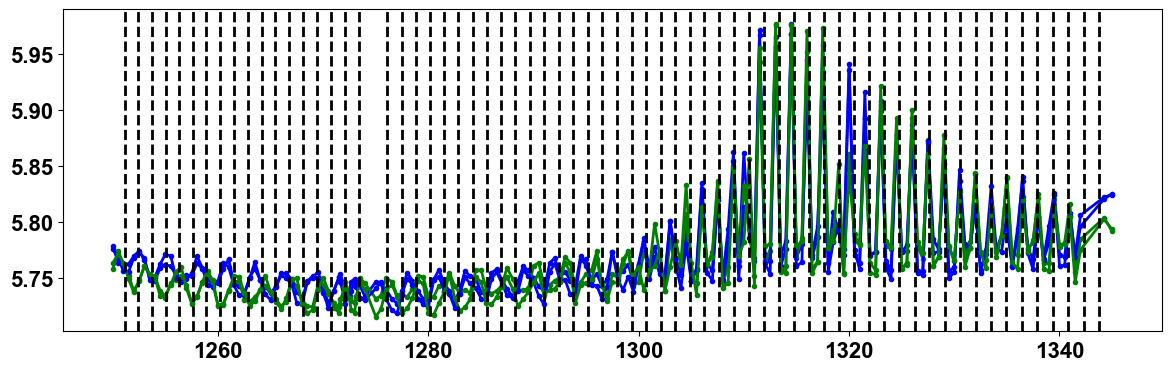

In [34]:
dir_name = "Sample_GSdev1b_hyperspectral_image_2025-11-02-19-20-23"
fname ="HyperspecImg_Nikon20x_N150_CaroteneDiamond_0.5nm_0.3ms_50min_2025-11-02-19-20-23_FIXGALVO_2025-11-05-18-29-06.h5"
# fname = "HyperspecImg_Nikon20x_N150_CaroteneDiamond_1nm_300us_85min_6tlia_12dbdec_2025-11-02-22-00-59.h5"
fpath = os.path.join(data_dir, dir_name)
ds = load_data_from_file(fpath, fname)

fig, ax = plot_daqsweep_wavmon(ds, id_sweep_dir=True, ds_type='hs_image', colors=['b','g'], figsize=(12,4))
plt.show()

In [ ]:
def plot_daqsweep_wavmon(ds, ds_type='sweep', id_sweep_dir=False, colors=['b','g'], ax=None, fig=None, figsize=(6,4), normalize=True, num_reps=None):
    """
    ds_type: 'sweep': single point daq sweeps, 'hs_im': hyperspectral image
    """
    #Load FFP peaks from calibration file
    fpath = os.path.join(calib_dir,'FFP-I_peaks')
    FFP_cal_pks = load_hdf5(fpath=fpath)
    cal_pks = FFP_cal_pks["peaks"]
    
    
    #restrict FFP_cal_pks to tuning range
    FFP_cal = cal_pks[(cal_pks >= np.nanmin(ds['wavelength_set'])) & (cal_pks <= np.nanmax(ds['wavelength_set']))] 
    FFP_cal = FFP_cal[~((FFP_cal > ds['wavelength_set'][0]) & (FFP_cal < ds['wavelength_set'][-1]))]

    if ds_type == 'sweep':
        wavset_sort, s_ind = np.unique(ds["wavelength_set"].to(u.nm).m, return_index=True)
        wavset_sort = wavset_sort * u.nm
        wavmon_arr = ds["VCSEL_wavmon_arr"][:, s_ind]
    elif ds_type == 'hs_image':
        wavset_sort = ds["wavset_sort"]
        wavmon_arr = ds["VCSEL_wavmon_pix"]
    else:
        raise ValueError("Specify ds_type='hs_image' or 'sweep'")
    #Plotting
    even_color = colors[0]
    odd_color = even_color
    if id_sweep_dir:
        odd_color=colors[1]

    if num_reps is None:
        num_reps = wavmon_arr.shape[0]
    
    if normalize:
        for row in range(num_reps):
            # remove voltage offset
            wavmon_arr[row,:] = wavmon_arr[row,:] - np.min(wavmon_arr[row])
            # normalize to max
            wavmon_arr[row,:] = wavmon_arr[row,:] / np.max(wavmon_arr[row].m)
    
    if ax is None:
        fig, ax = plt.subplots(1,1, figsize=figsize, tight_layout=True)
        
    for row in range(num_reps):
        if row %2 != 0:
            ax.plot(wavset_sort, wavmon_arr[row], '.-', color=odd_color)
        else:
            ax.plot(wavset_sort, wavmon_arr[row], '.-', color=even_color)

    for wn in FFP_cal.m:
        plt.axvline(wn, color='k', linestyle='--')
    return fig, ax

loading file: Spectra_test_FFP_GS_step0.1nm_100us_5tlia_noDichroic_30dB_100reps_2025-11-07-16-47-40.h5
importing Dev2...
importing HVA_Vraw...
importing HVA_Vset...
importing HV_arr...
importing VCSEL_wavmon_arr...
importing VCSEL_wavmon_raw...
importing VOA_Vset...
importing Vsrs_Vraw...
importing Vsrs_arr...
importing raman_shift...
importing t...
importing wavelength_set...
importing attr num_sweep...
importing attr pump_wav...
nanometer
importing attr pump_wav_units...
importing attr sens_lia...
millivolt
importing attr sens_lia_units...
importing attr t_lia...
millisecond
importing attr t_lia_units...
importing attr wav_start...
nanometer
importing attr wav_start_units...
importing attr wav_stop...
nanometer
importing attr wav_stop_units...
importing attr Δwav...
nanometer
importing attr Δwav_units...
loading file: Spectra_test_FFP_GS_step1nm_100us_5tlia_noDichroic_30dB_100reps_2025-11-07-17-01-05.h5
importing Dev2...
importing HVA_Vraw...
importing HVA_Vset...
importing HV_arr...

c:\Users\Goldfish\miniforge3\envs\tidy3d\Lib\site-packages\matplotlib\cbook.py:1355: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asarray(x, float)


loading file: FFP-I_peaks
importing peaks...


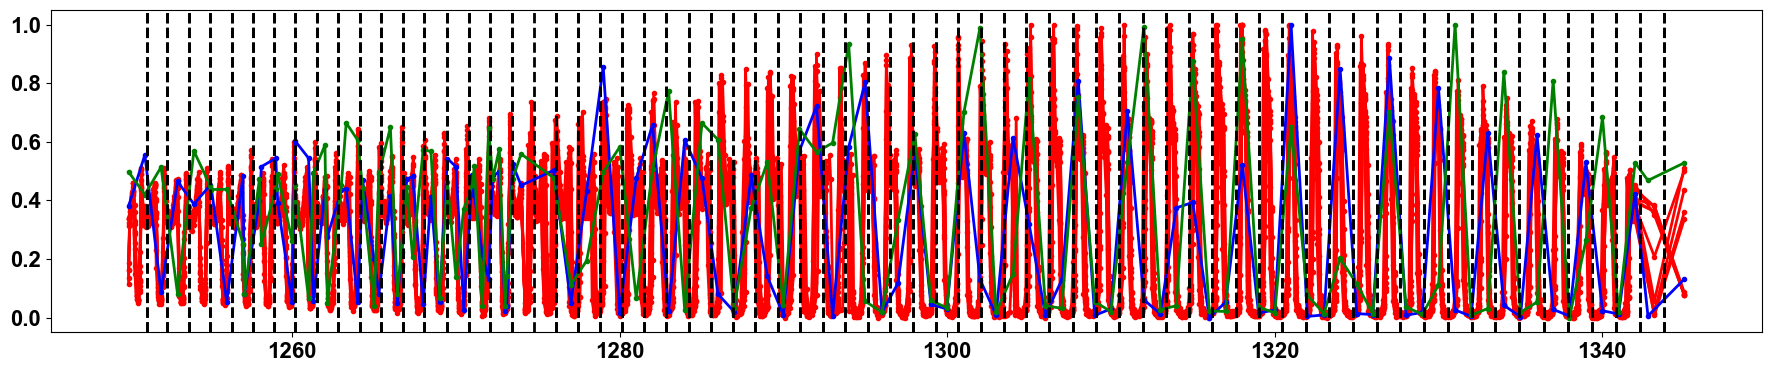

In [ ]:
# For DAQ sweep

dir_name = "Sample_GSdev1b_Nikon20x_delayvolt16_2025-11-02-18-06-04"
fname ="Spectra_test_FFP_GS_step0.1nm_100us_5tlia_noDichroic_30dB_100reps_2025-11-07-16-47-40.h5"
fpath = os.path.join(data_dir, dir_name)
ds = load_data_from_file(fpath, fname)


dir_name = "Sample_GSdev1b_Nikon20x_delayvolt16_2025-11-02-18-06-04"
# fname2 ="Spectra_test_FFP_GS_step0.1nm_100us_5tlia_noDichroic_30dB_100reps_2025-11-07-16-47-40.h5"  #Repeat 100us
# fname2 ="Spectra_test_FFP_GS_step0.1nm_300us_5tlia_noDichroic_30dB_100reps_2025-11-07-16-51-30.h5"  #Compare to 300us
# fname2 = "Spectra_test_FFP_GS_step0.1nm_100us_Dichroic_60dB_2025-11-06-21-00-01.h5" #Compare to dichroic, 100us
# fname2 = "Spectra_test_FFP_GS_step1nm_100us_5tlia_noDichroic_30dB_100reps_2025-11-07-17-01-05.h5"  #Compare to 1nm step

fpath2 = os.path.join(data_dir, dir_name)
# ds2 = load_data_from_file(fpath2, fname2)

cal_pks = FFP_cal_pks["peaks"]
wavset_sort, s_ind = np.unique(ds["wavelength_set"].to(u.nm).m, return_index=True)
wavset_sort = wavset_sort * u.nm

#restrict FFP_cal_pks to tuning range
FFP_cal = cal_pks[(cal_pks >= np.nanmin(ds['wavelength_set'])) & (cal_pks <= np.nanmax(ds['wavelength_set']))] 
FFP_cal = FFP_cal[~((FFP_cal > ds['wavelength_set'][0]) & (FFP_cal < ds['wavelength_set'][-1]))]

%matplotlib inline
fig, ax = plot_daqsweep_wavmon(ds, id_sweep_dir=False, colors=['r','k'], figsize=(18,4), normalize=True, num_reps=10)
# fig, ax = plot_daqsweep_wavmon(ds2, id_sweep_dir=True, colors=['b','g'], ax=ax, figsize=(12,4), normalize=True, num_reps=2)
plt.show()



In [42]:
#id peaks on 0.1nm sweep

from scipy.signal import find_peaks

peak_wls = []

wavset_sort, s_ind = np.unique(ds["wavelength_set"].to(u.nm).m, return_index=True)
wavset_sort = wavset_sort * u.nm
wavmon_arr = ds["VCSEL_wavmon_arr"][:, s_ind]

# print(wavmon_arr.shape)
# Find peaks in sweep unwrapped spectra, append wavelength of peaks to vector
for row in range(wavmon_arr.shape[0]):
    FFP_pks_ind, _ = find_peaks(wavmon_arr[row], distance=7, height=6.5)
    FFP_pks = wavset_sort[FFP_pks_ind]
    peak_wls.extend(FFP_pks.m)

print(peak_wls)
# FFP_pks, _ = find_peaks(ds['VCSEL_wavmon_raw'], distance=7, height=6.5)
# print(f"FFP_pks: {FFP_pks}")

# Plot histogram of id'd peaks

# reject peaks with few counts / xx std from peak norm


# for row in range(4):
#     if row %2 != 0:
#         ax.plot(wavset_sort, wavmon_arr[row], '.-', color=odd_color)
#     else:
#         ax.plot(wavset_sort, wavmon_arr[row], '.-', color=even_color)

# plt.figure(figsize=(4,3))
# plt.plot(ds['t'], ds['VCSEL_wavmon_raw'])
# plt.plot(ds['t'][FFP_pks], ds['VCSEL_wavmon_raw'][FFP_pks], 'x')
# plt.xlabel("Time (s)")
# plt.ylabel("wavmon")

[np.float64(1250.7949937421777), np.float64(1252.2037546933666), np.float64(1253.5038798498122), np.float64(1254.7969962453064), np.float64(1256.0988735919898), np.float64(1257.5006257822279), np.float64(1258.7972465581977), np.float64(1260.1026282853566), np.float64(1261.3992490613266), np.float64(1262.6958698372964), np.float64(1263.9994993742177), np.float64(1264.7003754693367), np.float64(1265.4012515644556), np.float64(1266.1021276595745), np.float64(1267.3987484355441), np.float64(1268.099624530663), np.float64(1269.2981226533166), np.float64(1270.002503128911), np.float64(1270.7016270337922), np.float64(1271.9982478097622), np.float64(1273.3001251564456), np.float64(1274.4180225281602), np.float64(1275.188986232791), np.float64(1275.959949937422), np.float64(1276.7309136420524), np.float64(1277.4773466833542), np.float64(1278.9071339173968), np.float64(1279.664080100125), np.float64(1280.4210262828535), np.float64(1281.177972465582), np.float64(1281.9349186483105), np.float64(12

c:\Users\Goldfish\miniforge3\envs\tidy3d\Lib\site-packages\scipy\signal\_peak_finding.py:266: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  value = np.asarray(value, order='C', dtype=np.float64)


loading file: Spectra_test_FFP_GS_step0.5nm_100us_60dB_2025-11-06-19-24-22.h5
importing Dev2...
importing HVA_Vraw...
importing HVA_Vset...
importing HV_arr...
importing VCSEL_wavmon_arr...
importing VCSEL_wavmon_raw...
importing VOA_Vset...
importing Vsrs_Vraw...
importing Vsrs_arr...
importing raman_shift...
importing t...
importing wavelength_set...
importing attr num_sweep...
importing attr pump_wav...
nanometer
importing attr pump_wav_units...
importing attr sens_lia...
millivolt
importing attr sens_lia_units...
importing attr t_lia...
millisecond
importing attr t_lia_units...
importing attr wav_start...
nanometer
importing attr wav_start_units...
importing attr wav_stop...
nanometer
importing attr wav_stop_units...
importing attr Δwav...
nanometer
importing attr Δwav_units...


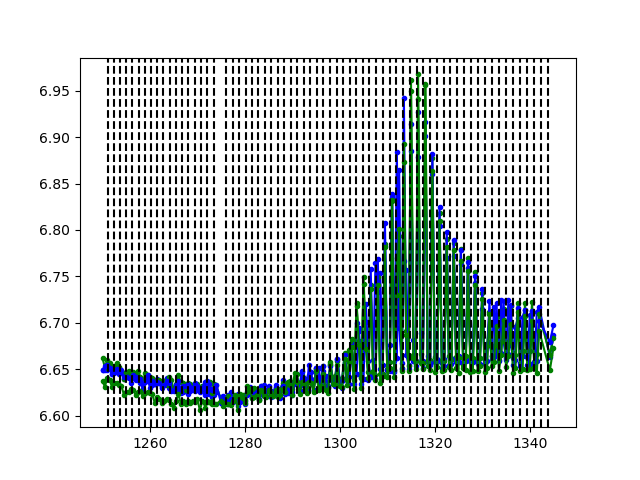

In [31]:
t_scan = ds["t_scan"]
t_sweep = ds["t_sweep"]
pad = 5
offset = 0
nx = ds['Vsrs_g'].shape[0]
ny = ds['Vsrs_g'].shape[1]

# d_spot = 1.8*u.um
# N = nx
# Vscan, Lscan = get_Nyquist_vals(N=N, d_spot=d_spot)
pad_galvo_endpts = 1
# fixed_wav = 1074.4 * u.nm

# ΔVx = 0.516*u.V
# ΔVy = ΔVx

#Sort wavelength by ascending order and remove repeated values
# s_ind = np.argsort(wavelength_set)
# wavset_sort = wavelength_set[s_ind]
wavset_sort, s_ind = np.unique(ds["wavelength_set"].to(u.nm).m, return_index=True)
wavset_sort = wavset_sort * u.nm

Vsrs_raw = ds['Dev2']['ai0']
HV_raw = Vmon_to_HVA(ds['Dev2']['ai1'])
VCSEL_wavmon_raw = ds['Dev2']['ai3']

#Remove padded samples at endpoints of daq2 arrays
Vsrs_raw = Vsrs_raw[pad:-pad]
HV_raw = HV_raw[pad:-pad]
VCSEL_wavmon_raw = VCSEL_wavmon_raw[pad:-pad]

#Reshape into 2d array with n_pix rows
num_pix = nx*ny 
npix = num_pix + 1
N_wav = Vsrs_raw.shape[0] // npix
N_unqwav = s_ind.shape[0]

print(f"npix: {npix}")
print(f"Vsrs_raw.shape[0]: {Vsrs_raw.shape[0]}")
print(f"N_wav: {N_wav}")
print(f"N_unqwav: {N_unqwav}")

Vsrs_pix = np.reshape(np.array(Vsrs_raw.to(u.V).m), (npix, N_wav))
HV_pix = np.reshape(np.array(HV_raw.to(u.V).m), (npix, N_wav))
VCSEL_wavmon_pix = np.reshape(np.array(VCSEL_wavmon_raw.to(u.V).m), (npix, N_wav))

#Discard 1st pixel sweep (first row) - galvo ai reads garbage here
#Discard pad_galvo_endpts points from the start of each row - vcsel ai lags ao
Vsrs_pix = Vsrs_pix[:-1,pad_galvo_endpts:]
HV_pix = HV_pix[:-1,pad_galvo_endpts:] 
VCSEL_wavmon_pix = VCSEL_wavmon_pix[:-1,pad_galvo_endpts:]


# Initialize arrays for pixel x spectra with sorted, unique spectral points
Vsrs_unqpix = np.zeros((num_pix, N_unqwav))
HV_unqpix = np.zeros((num_pix, N_unqwav))
VCSEL_wavmon_unqpix = np.zeros((num_pix, N_unqwav))

#Odd pixels are backward sweeps - flip (Assumes only 1 num_sweeps per pix is 1)
for row in range(Vsrs_pix.shape[0]):
    if row % 2 != 0:
        Vsrs_pix[row,:] = Vsrs_pix[row,::-1]
        HV_pix[row,:] = HV_pix[row,::-1]
        VCSEL_wavmon_pix[row,:] = VCSEL_wavmon_pix[row,::-1]
    # Sort columns (wavelength sweep) by ascending order and remove repeated values
    # Vsrs_unqpix[row,:] = Vsrs_pix[row, s_ind]
    # HV_unqpix[row,:] = HV_pix[row, s_ind]
    # VCSEL_wavmon_unqpix[row,:] = VCSEL_wavmon_pix[row, s_ind]
    
    
    

npix: 10001
Vsrs_raw.shape[0]: 2000200
N_wav: 200
N_unqwav: 190


NameError: name 'VCSEL_wavmon_pix' is not defined

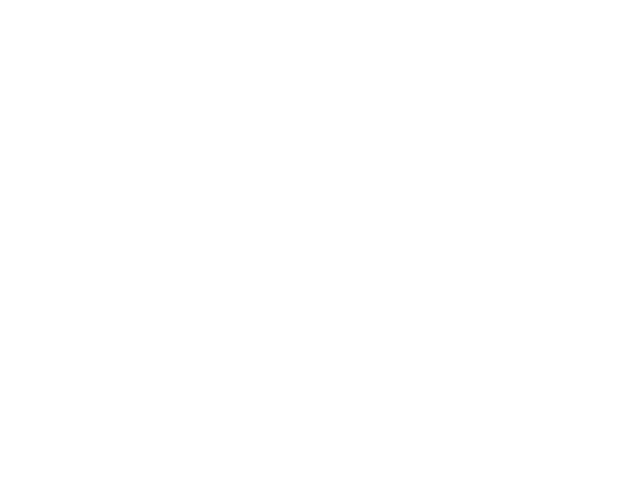

In [30]:
plt.figure()
# plt.plot(ds['t_sweep'], ds['Dev2']['ai3'])
for row in range(30):
    if row %2 != 0:
        plt.plot(range(VCSEL_wavmon_pix.shape[1]), VCSEL_wavmon_pix[row,:].T, '.-', color='g')
    else:
        plt.plot(range(VCSEL_wavmon_pix.shape[1]), VCSEL_wavmon_pix[row,:].T, '.-', color='b')
# plt.xlim((0,1))

plt.figure()
for row in range(31, 51):
    if row %2 != 0:
        plt.plot(range(VCSEL_wavmon_pix.shape[1]), Vsrs_pix[row,:].T, '.-', color = 'g')
    else:
        plt.plot(range(VCSEL_wavmon_pix.shape[1]), Vsrs_pix[row,:].T, '.-', color = 'b')

plt.figure()
for row in range(7000, 9000):
    if row %2 != 0:
        plt.plot(range(VCSEL_wavmon_pix.shape[1]), Vsrs_pix[row,:].T, '.-', color = 'g')
    else:
        plt.plot(range(VCSEL_wavmon_pix.shape[1]), Vsrs_pix[row,:].T, '.-', color = 'b')




In [776]:
ds["VCSEL_wavmon_pix"][0:2,:].shape

(2, 190)

c:\Users\euyehara\miniconda3\envs\instrumental\Lib\site-packages\matplotlib\cbook.py:1398: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asarray(x, float)


(0.0, 0.4)

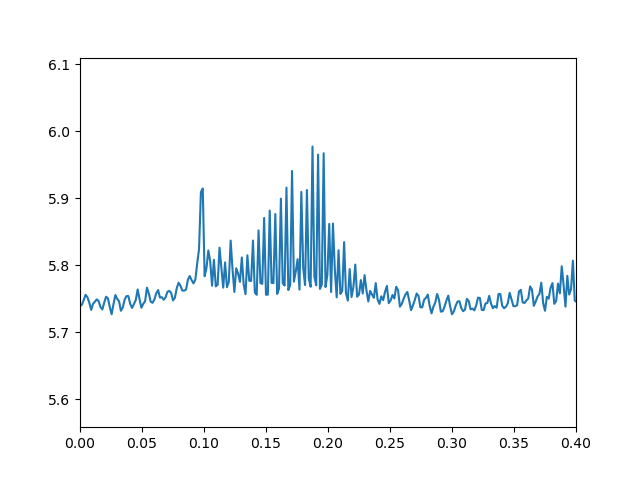

In [815]:
plt.figure()
plt.plot(ds['t_sweep'], ds['Dev2']['ai3'])
plt.xlim((0,0.4))

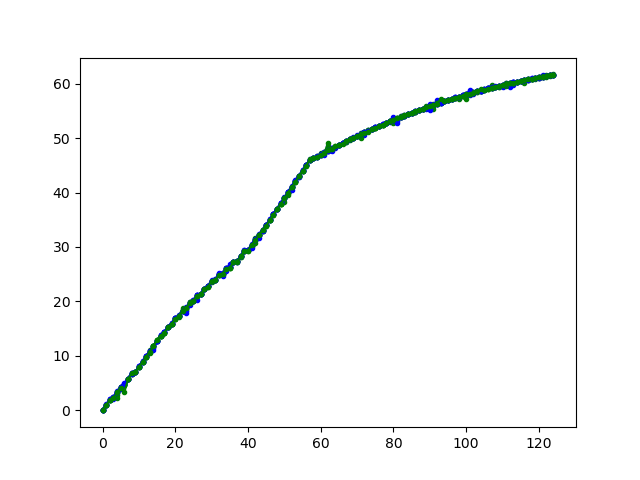

In [839]:
plt.figure()
for row in range(10000, 10010):
    if row %2 != 0:
        plt.plot(range(HV_pix.shape[1]), HV_pix[row,:].T, '.-', color = 'g')
    else:
        plt.plot(range(HV_pix.shape[1]), HV_pix[row,:].T, '.-', color = 'b')
